## SVM Kernel Practical Implementation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [3]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

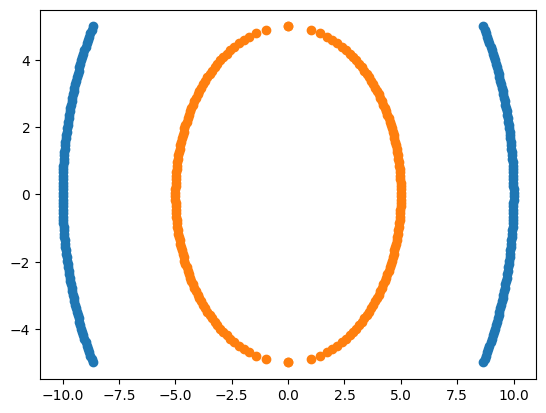

In [4]:

plt.scatter(y,x)
plt.scatter(y1,x1)

In [5]:
import pandas as pd
df1 = pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1

# Use pd.concat instead of append
df = pd.concat([df1, df2], ignore_index=True)
# df = df1.append(df2)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [6]:
df.tail()

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


## Polynomial Kernel

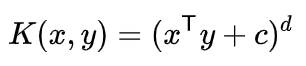

Based on the formula find the componenets for the Polynomial kernel

In [7]:
df['X1_Square']=df['X1']**2
df['X2_Square']=df['X2']**2
df['X1*X2']=df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [8]:
### Independent and Dependent features
X = df[['X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = 0)

In [10]:
X_train.head()

,X1_Square,X2_Square,X1*X2
250,24.997449,0.002551,0.252512
63,98.140496,1.859504,13.508984
312,10.651974,14.348026,-12.362637
159,99.079176,0.920824,9.551676
283,13.549638,11.450362,12.455852


In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
# !pip install plotly

In [13]:
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [14]:
import plotly.express as px
import plotly.express as px
fig = px.scatter_3d(df, x='X1_Square', y='X2_Square', z='X1*X2',
              color='Y')
fig.show()
plt.show()

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

## 📌 **Radial Basis Function (RBF) Kernel**

The **RBF kernel** on two samples **x ∈ ℝⁿ** and **x′**, represented as feature vectors in the input space, is defined as:

$$
K(x, x') = \exp(-\gamma \|x - x'\|^2)
$$

$$
K(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)
$$

where:  
- $ \|x - x'\|^2 $ is the **squared Euclidean distance** between the two feature vectors.  
- $ \gamma $ (gamma) is a **free parameter** that defines the influence of a single training example.

---

📌 **Alternative Form:**

Sometimes, the RBF kernel is also expressed using:

$$
\gamma = \frac{1}{2\sigma^2}
$$

Here, $ \sigma $ (sigma) is a **parameter that controls the spread** of the kernel.

---

In [17]:
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [18]:
## Indpeendent Features
X=df.iloc[:,0:2]
y=df.Y

In [19]:
X.head()

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596


In [20]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = 0)

In [22]:
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [23]:
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

0.59

## Sigmoid Kernel

The Sigmoid Kernel is a type of kernel function used in machine learning algorithms like Support Vector Machines (SVM). It maps the input data into a higher-dimensional space, making it easier to find a separating hyperplane for non-linear data. The two common forms of the Sigmoid function are:

1. **Standard Sigmoid Function**:
   $$
   S(x) = \frac{1}{1 + e^{-x}}
   $$
   Where:
   - $ e $ is the base of the natural logarithm,
   - $ x $ is the input value.

2. **Alternative Sigmoid Function**:
   $$
   S(x) = \frac{e^x}{e^x + 1}
   $$
   This is algebraically equivalent to the first form, as both describe the same S-shaped curve.

### Properties:
- It is used to introduce non-linearity in models.
- Commonly applied in neural networks and SVMs.
- The kernel function helps in transforming data into a higher-dimensional space, facilitating the separation of complex datasets.

Both functions are effective in handling problems where the decision boundary is not linear.

In [24]:
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

0.51

#### ChatGPT
## Polynomial Kernel

In [26]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Sample Data (use your actual df)
# Assuming df has columns: X1_Square, X2_Square, X1*X2, Y

# Create the 3D scatter plot
scatter = go.Scatter3d(
    x=df['X1_Square'],
    y=df['X2_Square'],
    z=df['X1*X2'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['Y'],
        colorscale='plasma',
        opacity=0.8,
        colorbar=dict(title='Y')
    )
)

# Set up the layout with frames for rotation
frames = []
for angle in range(0, 360, 2):
    frames.append(go.Frame(layout=dict(scene_camera=dict(eye=dict(x=np.cos(np.radians(angle)), 
                                                                  y=np.sin(np.radians(angle)), 
                                                                  z=0.5)))))

# Layout with animation settings
layout = go.Layout(
    title='Auto-Rotating 3D Scatter Plot',
    scene=dict(
        xaxis_title='X1_Square',
        yaxis_title='X2_Square',
        zaxis_title='X1*X2'
    ),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(label='Play',
                      method='animate',
                      args=[None, dict(frame=dict(duration=50, redraw=True),
                                       fromcurrent=True,
                                       mode='immediate')])]
    )]
)

# Create the figure
fig = go.Figure(data=[scatter], layout=layout, frames=frames)
fig.show()
